In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All imports done ✅")

All imports done ✅


In [4]:
df = pd.read_csv('data/GlobalWeatherRepository.csv')
df['last_updated'] = pd.to_datetime(df['last_updated'])
df = df.sort_values('last_updated').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['last_updated'].min()} → {df['last_updated'].max()}")
print(f"Countries: {df['country'].nunique()} | Cities: {df['location_name'].nunique()}")
print(f"Missing values: {df.isnull().sum().sum()} ✅")
df.head()

Shape: (137413, 41)
Date range: 2024-05-16 01:45:00 → 2026-04-24 19:30:00
Countries: 211 | Cities: 257
Missing values: 0 ✅


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,United States of America,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,16.1,61.0,Clear,...,6.3,7.1,1,1,05:26 AM,08:31 PM,01:36 PM,02:52 AM,Waxing Gibbous,55
1,Honduras,Tegucigalpa,14.10,-87.22,America/Tegucigalpa,1715849100,2024-05-16 02:45:00,23.0,73.4,Partly cloudy,...,19.0,25.3,2,2,05:22 AM,06:09 PM,12:52 PM,12:55 AM,Waxing Gibbous,55
2,El Salvador,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,26.0,78.8,Moderate or heavy rain with thunder,...,20.4,28.1,2,2,05:30 AM,06:16 PM,01:00 PM,01:02 AM,Waxing Gibbous,55
3,Guatemala,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,20.0,68.0,Mist,...,132.0,178.1,4,10,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55
4,Belize,Belmopan,17.25,-88.77,America/Belize,1715849100,2024-05-16 02:45:00,26.0,78.9,Overcast,...,7.7,32.1,1,1,05:23 AM,06:20 PM,12:56 PM,01:04 AM,Waxing Gibbous,55


In [5]:
# Redundant columns drop karo
cols_to_drop = ['temperature_fahrenheit', 'feels_like_fahrenheit',
                'wind_mph', 'pressure_in', 'precip_in',
                'visibility_miles', 'gust_mph',
                'last_updated_epoch']
df.drop(columns=cols_to_drop, inplace=True)

# Feature engineering
df['hour'] = df['last_updated'].dt.hour
df['month'] = df['last_updated'].dt.month
df['day_of_week'] = df['last_updated'].dt.dayofweek
df['season'] = df['month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Autumn',10:'Autumn',11:'Autumn'
})

print("Cleaning done ✅")
print(f"Final shape: {df.shape}")
print(f"New columns added: hour, month, day_of_week, season")

Cleaning done ✅
Final shape: (137413, 37)
New columns added: hour, month, day_of_week, season


In [7]:
fig = px.box(df, x='season', y='temperature_celsius',
             color='season',
             title='Temperature Distribution by Season',
             labels={'temperature_celsius': 'Temperature (°C)'})
fig.show()

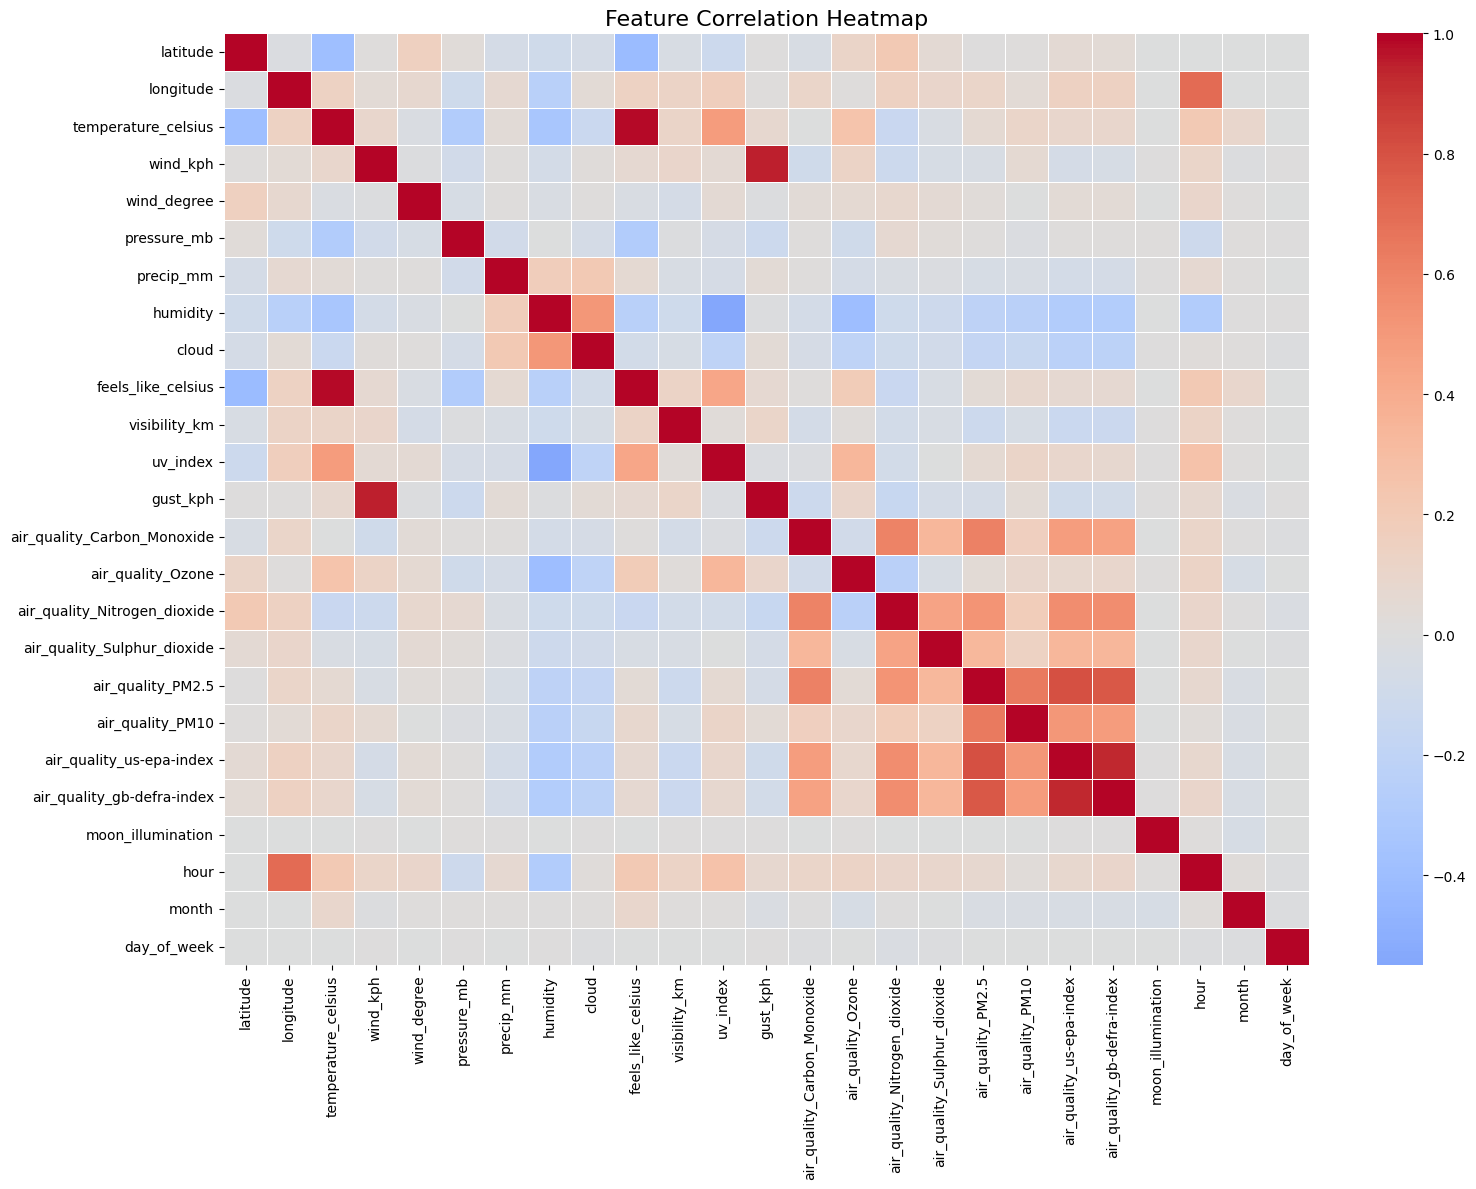

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0,
            annot=False, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150)
plt.show()

In [10]:
country_avg = df.groupby('country').agg(
    avg_temp=('temperature_celsius','mean'),
    avg_aqi=('air_quality_us-epa-index','mean'),
    lat=('latitude','first'),
    lon=('longitude','first')
).reset_index()

fig = px.scatter_geo(country_avg,
                     lat='lat', lon='lon',
                     color='avg_temp',
                     hover_name='country',
                     size='avg_aqi',
                     color_continuous_scale='RdYlBu_r',
                     title='Global Average Temperature & AQI by Country',
                     projection='natural earth')
fig.show()

In [11]:
features = ['temperature_celsius','humidity','wind_kph',
            'pressure_mb','precip_mm','air_quality_PM2.5']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

iso = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso.fit_predict(X_scaled)
df['anomaly_label'] = df['anomaly'].map({1:'Normal', -1:'Anomaly'})

print(f"Anomalies detected: {(df['anomaly']==-1).sum()} ({(df['anomaly']==-1).mean()*100:.1f}%)")

fig = px.scatter(df.sample(5000), x='last_updated', y='temperature_celsius',
                 color='anomaly_label',
                 color_discrete_map={'Normal':'steelblue','Anomaly':'red'},
                 title='Anomaly Detection in Temperature (Isolation Forest)',
                 opacity=0.6)
fig.show()

Anomalies detected: 6871 (5.0%)


In [12]:
fig = px.scatter(df.sample(5000), 
                 x='temperature_celsius', 
                 y='air_quality_PM2.5',
                 color='humidity',
                 size='wind_kph',
                 hover_name='country',
                 color_continuous_scale='RdYlGn_r',
                 title='Air Quality (PM2.5) vs Temperature & Humidity',
                 labels={'temperature_celsius': 'Temperature (°C)',
                         'air_quality_PM2.5': 'PM2.5'})
fig.show()

In [14]:
features = ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb',
            'precip_mm', 'cloud', 'visibility_km', 'uv_index',
            'air_quality_PM2.5', 'air_quality_Ozone',
            'air_quality_Carbon_Monoxide', 'hour', 'month', 'day_of_week']

X = df[features]
y = df['feels_like_celsius']

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig = px.bar(importance_df, x='importance', y='feature',
             orientation='h',
             title='Feature Importance for Feels Like Temperature',
             color='importance',
             color_continuous_scale='Blues')
fig.show()


In [15]:
# Top 10 countries by data points
top_countries = df['country'].value_counts().head(10).index.tolist()
df_top = df[df['country'].isin(top_countries)]

monthly_avg = df_top.groupby(['country', 'month'])['temperature_celsius'].mean().reset_index()

fig = px.line(monthly_avg, 
              x='month', 
              y='temperature_celsius',
              color='country',
              title='Monthly Average Temperature by Country (Climate Analysis)',
              labels={'temperature_celsius': 'Avg Temperature (°C)',
                      'month': 'Month'},
              markers=True)
fig.update_xaxes(tickvals=list(range(1,13)),
                 ticktext=['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
fig.show()

In [16]:
from prophet import Prophet

# Sirf ek city lo - London
city_df = df[df['location_name'] == 'London'][['last_updated', 'temperature_celsius']].copy()
city_df.columns = ['ds', 'y']
city_df = city_df.sort_values('ds').reset_index(drop=True)

print(f"London data points: {len(city_df)}")

# Train/Test split - last 30 days test
split_date = city_df['ds'].max() - pd.Timedelta(days=30)
train = city_df[city_df['ds'] <= split_date]
test = city_df[city_df['ds'] > split_date]

# Model
model = Prophet(daily_seasonality=True, weekly_seasonality=True)
model.fit(train)

# Forecast
future = model.make_future_dataframe(periods=len(test), freq='h')
forecast = model.predict(future)

# Plot
fig = px.line(title='Prophet Forecast - London Temperature')
fig.add_scatter(x=train['ds'], y=train['y'], name='Train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], name='Actual', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'].tail(len(test)), 
                y=forecast['yhat'].tail(len(test)), 
                name='Forecast', line=dict(color='red', dash='dash'))
fig.show()

# Metrics
y_true = test['y'].values
y_pred = forecast['yhat'].tail(len(test)).values
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"\nProphet Results:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.2f}")

London data points: 704


00:49:38 - cmdstanpy - INFO - Chain [1] start processing
00:49:40 - cmdstanpy - INFO - Chain [1] done processing



Prophet Results:
RMSE: 19.83
MAE:  14.08
R²:   -42.87


In [18]:
import xgboost as xgb

# London data with lag features
city_df2 = df[df['location_name'] == 'London'][['last_updated', 'temperature_celsius']].copy()
city_df2 = city_df2.sort_values('last_updated').reset_index(drop=True)

# Lag features banana
city_df2['lag_1'] = city_df2['temperature_celsius'].shift(1)
city_df2['lag_6'] = city_df2['temperature_celsius'].shift(6)
city_df2['lag_24'] = city_df2['temperature_celsius'].shift(24)
city_df2['rolling_mean_24'] = city_df2['temperature_celsius'].rolling(24).mean()
city_df2['rolling_std_24'] = city_df2['temperature_celsius'].rolling(24).std()
city_df2['hour'] = city_df2['last_updated'].dt.hour
city_df2['month'] = city_df2['last_updated'].dt.month
city_df2['day_of_week'] = city_df2['last_updated'].dt.dayofweek
city_df2.dropna(inplace=True)

# Train/Test split
split = int(len(city_df2) * 0.8)
train = city_df2.iloc[:split]
test = city_df2.iloc[split:]

feature_cols = ['lag_1','lag_6','lag_24','rolling_mean_24',
                'rolling_std_24','hour','month','day_of_week']

X_train, y_train = train[feature_cols], train['temperature_celsius']
X_test, y_test = test[feature_cols], test['temperature_celsius']

# Model
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, 
                               max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Plot
fig = px.line(title='XGBoost Forecast - London Temperature')
fig.add_scatter(x=test['last_updated'], y=y_test, name='Actual', line=dict(color='green'))
fig.add_scatter(x=test['last_updated'], y=y_pred_xgb, name='XGBoost Forecast', 
                line=dict(color='orange', dash='dash'))
fig.show()

# Metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score

In [19]:
# Dono models ke predictions combine karo
# Prophet predictions already hain forecast mein
prophet_preds = forecast['yhat'].tail(len(test)).values[:len(y_pred_xgb)]
xgb_preds = y_pred_xgb

# Weighted ensemble (XGBoost ko zyada weight kyunki R² better tha)
ensemble_preds = (0.4 * prophet_preds) + (0.6 * xgb_preds)

# Common index ke liye test data trim karo
y_true_ensemble = y_test.values[:len(ensemble_preds)]
test_dates = test['last_updated'].values[:len(ensemble_preds)]

# Plot
fig = px.line(title='Ensemble Forecast vs Actual - London Temperature')
fig.add_scatter(x=test_dates, y=y_true_ensemble, name='Actual', line=dict(color='green'))
fig.add_scatter(x=test_dates, y=prophet_preds, name='Prophet', line=dict(color='blue', dash='dot'))
fig.add_scatter(x=test_dates, y=xgb_preds, name='XGBoost', line=dict(color='orange', dash='dot'))
fig.add_scatter(x=test_dates, y=ensemble_preds, name='Ensemble', line=dict(color='red', dash='dash'))
fig.show()

# Metrics
rmse_ens = np.sqrt(mean_squared_error(y_true_ensemble, ensemble_preds))
mae_ens = mean_absolute_error(y_true_ensemble, ensemble_preds)
r2_ens = r2_score(y_true_ensemble, ensemble_preds)
print(f"\nEnsemble Results:")
print(f"RMSE: {rmse_ens:.2f}")
print(f"MAE:  {mae_ens:.2f}")
print(f"R²:   {r2_ens:.2f}")


Ensemble Results:
RMSE: 4.70
MAE:  3.33
R²:   -0.97


In [23]:
# Check karo kya available hai
print("Prophet test columns:", test.columns.tolist() if hasattr(test, 'columns') else "Not a dataframe")
print("XGBoost y_test type:", type(y_test))
print("Ensemble preds length:", len(ensemble_preds))
print("y_true_ensemble length:", len(y_true_ensemble))

Prophet test columns: ['last_updated', 'temperature_celsius', 'lag_1', 'lag_6', 'lag_24', 'rolling_mean_24', 'rolling_std_24', 'hour', 'month', 'day_of_week']
XGBoost y_test type: <class 'pandas.Series'>
Ensemble preds length: 136
y_true_ensemble length: 136


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score as r2_score_fn

# XGBoost metrics
rmse_x = float(np.sqrt(mean_squared_error(y_test.values, y_pred_xgb)))
mae_x = float(mean_absolute_error(y_test.values, y_pred_xgb))
r2_x = float(r2_score_fn(y_test.values, y_pred_xgb))

# Ensemble metrics
rmse_e = float(np.sqrt(mean_squared_error(y_true_ensemble, ensemble_preds)))
mae_e = float(mean_absolute_error(y_true_ensemble, ensemble_preds))
r2_e = float(r2_score_fn(y_true_ensemble, ensemble_preds))

# Prophet metrics (Cell 11 ke variables use karo)
prophet_test_preds = forecast['yhat'].tail(136).values
prophet_test_actual = y_true_ensemble  # same length

rmse_p = float(np.sqrt(mean_squared_error(prophet_test_actual, prophet_test_preds)))
mae_p = float(mean_absolute_error(prophet_test_actual, prophet_test_preds))
r2_p = float(r2_score_fn(prophet_test_actual, prophet_test_preds))

results = pd.DataFrame({
    'Model': ['Prophet', 'XGBoost', 'Ensemble'],
    'RMSE': [rmse_p, rmse_x, rmse_e],
    'MAE': [mae_p, mae_x, mae_e],
    'R²': [r2_p, r2_x, r2_e]
})

print("=" * 45)
print("        MODEL COMPARISON RESULTS")
print("=" * 45)
print(results.to_string(index=False))
print("=" * 45)

fig = px.bar(results.melt(id_vars='Model', var_name='Metric', value_name='Score'),
             x='Model', y='Score', color='Metric',
             barmode='group',
             title='Model Comparison — RMSE, MAE, R²')
fig.write_html('outputs/model_comparison.html')
print("Saved ✅")

        MODEL COMPARISON RESULTS
   Model     RMSE      MAE        R²
 Prophet 9.793868 5.261290 -7.547992
 XGBoost 3.574567 2.905884 -0.138682
Ensemble 4.704247 3.325746 -0.972131
Saved ✅
